In [2]:
# ============================================================
# PART 1 : IMPORTS + LOAD DATA
# ============================================================

!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

df = pd.read_excel("/kaggle/input/datasets/shlok192980707/customer-segmentation/Telco_customer_churn.xlsx")

print(df.shape)

df.head()

(7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

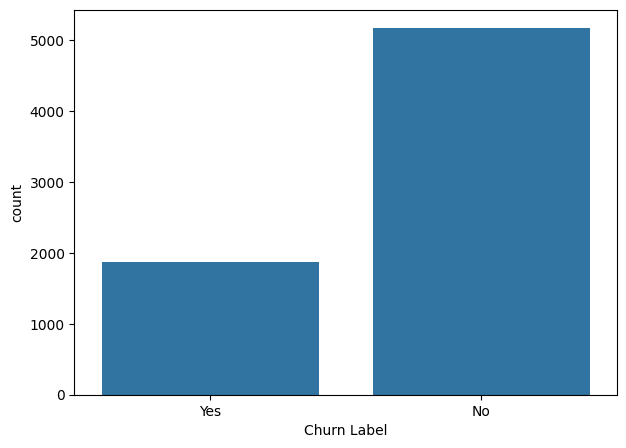

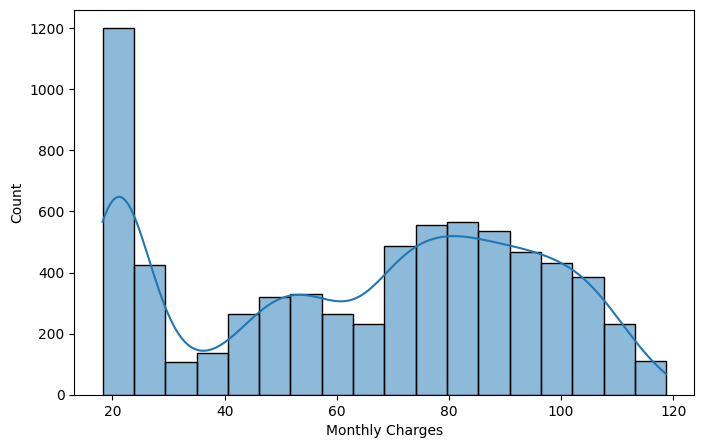

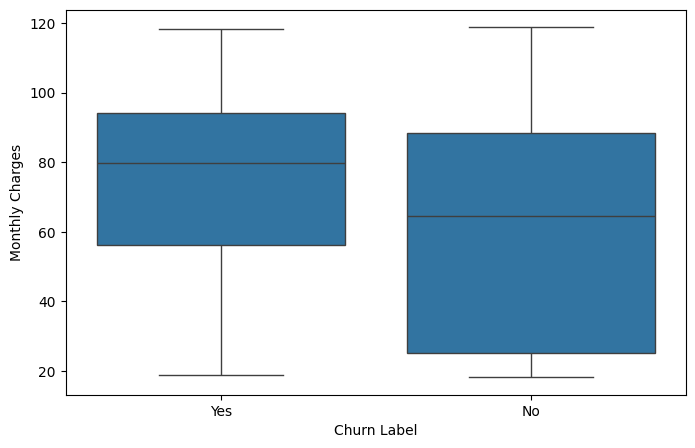

In [3]:
# ============================================================
# PART 2 : EDA
# ============================================================

print(df.info())

print(df.isnull().sum())

print(
df["Churn Label"]
.value_counts()
)

plt.figure(figsize=(7,5))

sns.countplot(
x="Churn Label",
data=df
)

plt.show()

plt.figure(figsize=(8,5))

sns.histplot(
df["Monthly Charges"],
kde=True
)

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(

x="Churn Label",

y="Monthly Charges",

data=df

)

plt.show()

In [4]:
# ============================================================
# PART 3 : PREPROCESSING
# ============================================================

df["Total Charges"] = pd.to_numeric(
df["Total Charges"],
errors="coerce"
)

df.fillna(
0,
inplace=True
)

drop_cols = [

'CustomerID',
'Count',
'Country',
'State',
'Zip Code',
'Latitude',
'Longitude',
'Lat Long',
'City',
'Churn Label',
'CLTV',
'Churn Reason'

]

df.drop(
columns=drop_cols,
errors="ignore",
inplace=True
)

df = pd.get_dummies(
df,
drop_first=True
)

X = df.drop(
"Churn Value",
axis=1
)

Y = df["Churn Value"]

print(
X.shape
)

(7043, 31)


In [5]:
# ============================================================
# PART 4 : SPLIT + SCALING
# ============================================================

X_train, X_test, Y_train, Y_test = train_test_split(

X,
Y,

test_size=0.2,

random_state=42,

stratify=Y

)

scaler = StandardScaler()

X_train = scaler.fit_transform(
X_train
)

X_test = scaler.transform(
X_test
)

print(
X_train.shape
)

(5634, 31)


In [6]:
# ============================================================
# PART 5 : SMOTE
# ============================================================

smote = SMOTE(
random_state=42
)

X_train_smote, Y_train_smote = (

smote.fit_resample(
X_train,
Y_train
)

)

print(
Y_train.value_counts()
)

print(
pd.Series(
Y_train_smote
).value_counts()
)

Churn Value
0    4139
1    1495
Name: count, dtype: int64
Churn Value
0    4139
1    4139
Name: count, dtype: int64


In [7]:
# ============================================================
# PART 6 : RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(

n_estimators=500,

max_depth=8,

class_weight="balanced",

random_state=42

)

rf.fit(

X_train_smote,

Y_train_smote

)

rf_pred = rf.predict(
X_test
)

print(

classification_report(

Y_test,

rf_pred

)

)

print(

"Accuracy:",

accuracy_score(

Y_test,

rf_pred

)

)

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      1035
           1       0.79      0.94      0.86       374

    accuracy                           0.92      1409
   macro avg       0.88      0.92      0.90      1409
weighted avg       0.93      0.92      0.92      1409

Accuracy: 0.9176721078779276


                                  Feature  Importance
3                             Churn Score    0.519679
0                           Tenure Months    0.076572
26                      Contract_Two year    0.068214
11           Internet Service_Fiber optic    0.044996
7                          Dependents_Yes    0.042594
29        Payment Method_Electronic check    0.033485
2                           Total Charges    0.032100
14                    Online Security_Yes    0.022887
25                      Contract_One year    0.019909
1                         Monthly Charges    0.018270
27                  Paperless Billing_Yes    0.017732
20                       Tech Support_Yes    0.013787
17  Device Protection_No internet service    0.008816
21       Streaming TV_No internet service    0.008751
13    Online Security_No internet service    0.007943
15      Online Backup_No internet service    0.007736
12                    Internet Service_No    0.007694
23   Streaming Movies_No int

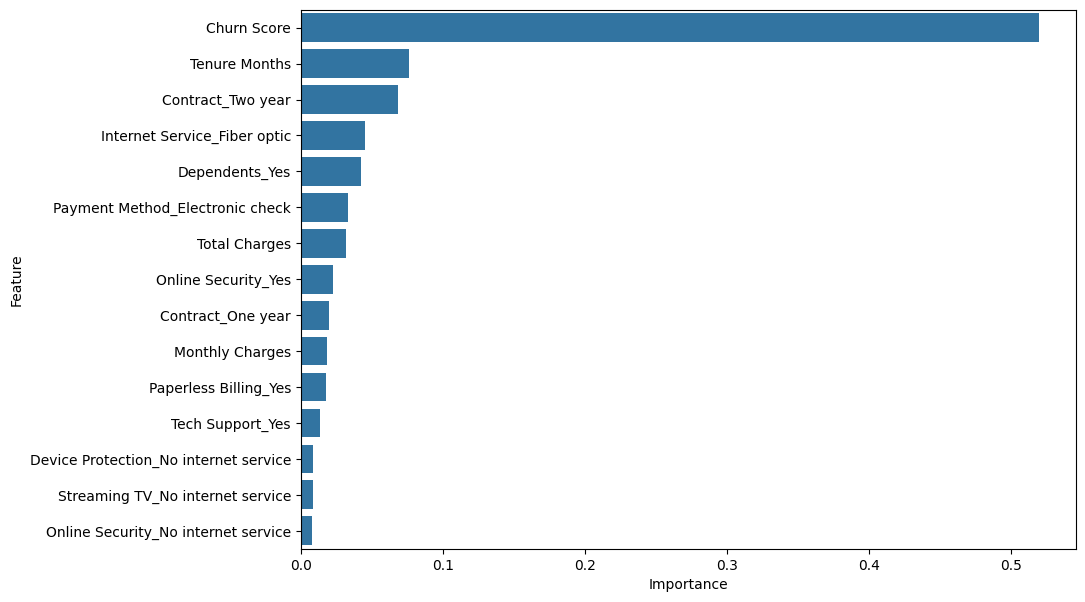

In [8]:
# ============================================================
# PART 7 : FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

"Feature":
X.columns,

"Importance":
rf.feature_importances_

})

importance = (

importance
.sort_values(
"Importance",
ascending=False
)

)

print(
importance.head(20)
)

plt.figure(
figsize=(10,7)
)

sns.barplot(

x="Importance",

y="Feature",

data=
importance.head(15)

)

plt.show()

In [9]:
# ============================================================
# PART 8 : GRID SEARCH
# ============================================================

params = {

"max_depth":[4,6,8],

"learning_rate":[0.01,0.03],

"n_estimators":[300,500]

}

grid = GridSearchCV(

XGBClassifier(
eval_metric="logloss"
),

params,

cv=3,

scoring="f1",

n_jobs=-1

)

grid.fit(

X_train_smote,

Y_train_smote

)

print(
grid.best_params_
)

{'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 500}


In [10]:
# ============================================================
# PART 9 : XGBOOST
# ============================================================

model = XGBClassifier(

**grid.best_params_,

subsample=0.9,

colsample_bytree=0.9,

random_state=42,

eval_metric="logloss"

)

model.fit(

X_train_smote,

Y_train_smote

)

pred = model.predict(
X_test
)

print(

classification_report(

Y_test,

pred

)

)

print(

accuracy_score(
Y_test,
pred
)

)

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1035
           1       0.82      0.90      0.86       374

    accuracy                           0.92      1409
   macro avg       0.89      0.92      0.90      1409
weighted avg       0.93      0.92      0.92      1409

0.9226401703335699


In [11]:
# ============================================================
# PART 10 : THRESHOLD TUNING
# ============================================================

prob = model.predict_proba(
X_test
)[:,1]

for t in [

0.35,
0.40,
0.45,
0.50

]:

    p = (
    prob>=t
    ).astype(int)

    print("\nThreshold:",t)

    print(

    classification_report(
    Y_test,
    p
    )

    )


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      1035
           1       0.79      0.93      0.85       374

    accuracy                           0.92      1409
   macro avg       0.88      0.92      0.90      1409
weighted avg       0.92      0.92      0.92      1409


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      1035
           1       0.80      0.93      0.86       374

    accuracy                           0.92      1409
   macro avg       0.88      0.92      0.90      1409
weighted avg       0.93      0.92      0.92      1409


Threshold: 0.45
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      1035
           1       0.81      0.92      0.86       374

    accuracy                           0.92      1409
   macro avg       0.89      0.92      0.90      1409
weighted avg       0.93 

In [12]:
# ============================================================
# PART 11 : MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

"Model":[
"RF",
"XGB"
],

"Accuracy":[

accuracy_score(
Y_test,
rf_pred
),

accuracy_score(
Y_test,
pred
)

]

})

print(
comparison
)

  Model  Accuracy
0    RF  0.917672
1   XGB  0.922640


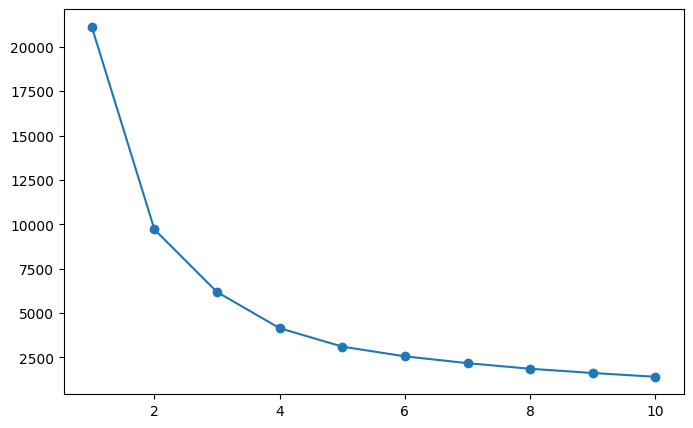

In [14]:
# ============================================================
# PART 12 : ELBOW METHOD
# ============================================================

seg = pd.read_excel("/kaggle/input/datasets/shlok192980707/customer-segmentation/Telco_customer_churn.xlsx")

seg["Total Charges"] = pd.to_numeric(
seg["Total Charges"],
errors="coerce"
)

seg.fillna(
0,
inplace=True
)

segment = seg[

[
"Tenure Months",
"Monthly Charges",
"Total Charges"
]

]

scale = StandardScaler()

scaled = scale.fit_transform(
segment
)

wcss=[]

for i in range(1,11):

    k = KMeans(

    n_clusters=i,

    random_state=42,

    n_init=10

    )

    k.fit(
    scaled
    )

    wcss.append(
    k.inertia_
    )

plt.figure(
figsize=(8,5)
)

plt.plot(

range(1,11),

wcss,

marker="o"

)

plt.show()

   Tenure Months  Monthly Charges  Total Charges  Cluster    Segment
0              2            53.85         108.15        1     Stable
1              2            70.70         151.65        1     Stable
2              8            99.65         820.50        1     Stable
3             28           104.80        3046.05        1     Stable
4             49           103.70        5036.30        2  High Risk


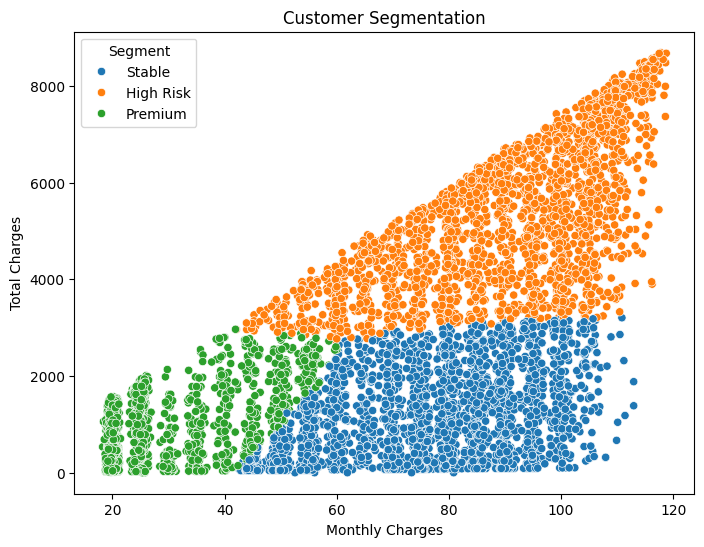

In [16]:
# ============================================================
# PART 13 : KMEANS (FIXED)
# ============================================================

# Create independent dataframe

segment = seg[

[
"Tenure Months",
"Monthly Charges",
"Total Charges"

]

].copy()

# Train KMeans

kmeans = KMeans(

n_clusters=3,

random_state=42,

n_init=10

)

# Predict cluster

segment.loc[
:,
"Cluster"
] = kmeans.fit_predict(
scaled
)

# Optional labels

cluster_map = {

0:"Premium",

1:"Stable",

2:"High Risk"

}

segment.loc[
:,
"Segment"
] = (

segment[
"Cluster"
]

.map(
cluster_map
)

)

print(
segment.head()
)

# Plot

plt.figure(
figsize=(8,6)
)

sns.scatterplot(

x="Monthly Charges",

y="Total Charges",

hue="Segment",

data=segment

)

plt.title(
"Customer Segmentation"
)

plt.show()